# 01. Preprocessing: Grain Segmentation with Cellpose

This notebook demonstrates the preprocessing pipeline used to turn a bulk
photograph of sake rice grains into individually segmented, rotation-corrected,
background-masked crops suitable for downstream classification.

Pipeline stages (see `src/sake_rice_inspection/preprocessing.py`):
1. **Segmentation** — Cellpose separates touching grains into instance masks.
2. **Noise reduction** — an area filter (default 1500 px) discards fragments
   that are too small to be a real grain.
3. **Normalization** — each grain is rotated so its major axis is vertical
   (via `regionprops` orientation) and the background is masked out, isolating
   texture information for the classifier.

> **Note on data**: the original grain photographs used in this research are
> subject to an NDA with the data-providing institutions and are not included
> in this repository. Point `CURATED_ROOT` below at your own directory of
> labeled grain photographs (one subfolder per class) to run this notebook.

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path("..") / "src"))

import matplotlib.font_manager as fm
import matplotlib.pyplot as plt

# Class names and source filenames are Japanese; the default font (DejaVu
# Sans) has no CJK glyphs, so plots would otherwise render missing-glyph
# boxes. Requires a CJK-capable font on the system (see Dockerfile);
# addfont() registers it explicitly since matplotlib's font cache may
# predate the font being installed. Only fonts actually installed in the
# image belong in this list: an unmatched entry (e.g. "IPAGothic", which
# isn't installed) makes matplotlib emit a "Font family not found" warning
# on every single font lookup, even though an earlier entry resolves fine.
_noto_cjk = Path("/usr/share/fonts/opentype/noto/NotoSansCJK-Regular.ttc")
if _noto_cjk.exists():
    fm.fontManager.addfont(str(_noto_cjk))
plt.rcParams["font.family"] = ["Noto Sans CJK JP", "DejaVu Sans"]
plt.rcParams["axes.unicode_minus"] = False

from cellpose import models

from sake_rice_inspection.preprocessing import process_directory, process_image_to_grains, render_overlay



Welcome to CellposeSAM, cellpose v4.0.1! The neural network component of
CPSAM is much larger than in previous versions and CPU excution is slow. 
We encourage users to use GPU/MPS if available. 




## Single-trait grains

Each label subfolder under `CURATED_ROOT` contains photographs of grains
exhibiting a single visual trait. `process_directory` walks every subfolder,
segments each photograph, and writes one crop + mask per grain.

In [2]:
cp_model = models.CellposeModel(gpu=True)

CURATED_ROOT = Path("/private/data/curated/reflect/single")
OUTPUT_ROOT = Path("/private/outputs/crops")
MASK_OUTPUT = Path("/private/outputs/mask")
CROP_MASK_OUTPUT = Path("/private/outputs/crops_mask")

stats = process_directory(
    CURATED_ROOT, OUTPUT_ROOT, MASK_OUTPUT, CROP_MASK_OUTPUT,
    model=cp_model, grouped_by_image=False, min_area=1500, diameter=50, margin=20,
)
stats

channels deprecated in v4.0.1+. If data contain more than 3 channels, only the first 3 channels will be used


/usr/local/lib/python3.10/site-packages/cellpose/dynamics.py:524: UserWarning: Sparse invariant checks are implicitly disabled. Memory errors (e.g. SEGFAULT) will occur when operating on a sparse tensor which violates the invariants, but checks incur performance overhead. To silence this warning, explicitly opt in or out. See `torch.sparse.check_sparse_tensor_invariants.__doc__` for guidance.  (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:760.)
  coo = torch.sparse_coo_tensor(pt, torch.ones(pt.shape[1], device=pt.device, dtype=torch.int),


channels deprecated in v4.0.1+. If data contain more than 3 channels, only the first 3 channels will be used


channels deprecated in v4.0.1+. If data contain more than 3 channels, only the first 3 channels will be used


channels deprecated in v4.0.1+. If data contain more than 3 channels, only the first 3 channels will be used


...

channels deprecated in v4.0.1+. If data contain more than 3 channels, only the first 3 channels will be used


channels deprecated in v4.0.1+. If data contain more than 3 channels, only the first 3 channels will be used


channels deprecated in v4.0.1+. If data contain more than 3 channels, only the first 3 channels will be used


channels deprecated in v4.0.1+. If data contain more than 3 channels, only the first 3 channels will be used


{'乳白': 236,
 '基白': 118,
 '心白': 112,
 '整粒': 244,
 '斑点': 100,
 '死米': 51,
 '病害': 100,
 '発芽': 100,
 '砕粒': 88,
 '背白': 55,
 '腹白': 72,
 '青未熟': 101}

## Composite-trait grains

Grains that exhibit multiple co-occurring traits (e.g. both Shinpaku and Base
White) are photographed and stored differently: each source photo gets its
own subfolder so its grains don't collide in ID with grains from other
photos in the same label. Pass `grouped_by_image=True` to get this layout.

In [3]:
CURATED_ROOT_COMPOSITE = Path("/private/data/curated/reflect/composite")
OUTPUT_ROOT_COMPOSITE = Path("/private/outputs/crops_composite")
MASK_OUTPUT_COMPOSITE = Path("/private/outputs/mask_composite")
CROP_MASK_OUTPUT_COMPOSITE = Path("/private/outputs/crops_mask_composite")

stats_composite = process_directory(
    CURATED_ROOT_COMPOSITE, OUTPUT_ROOT_COMPOSITE, MASK_OUTPUT_COMPOSITE, CROP_MASK_OUTPUT_COMPOSITE,
    model=cp_model, grouped_by_image=True, min_area=1500, diameter=50, margin=20,
)
stats_composite

channels deprecated in v4.0.1+. If data contain more than 3 channels, only the first 3 channels will be used


channels deprecated in v4.0.1+. If data contain more than 3 channels, only the first 3 channels will be used


channels deprecated in v4.0.1+. If data contain more than 3 channels, only the first 3 channels will be used


channels deprecated in v4.0.1+. If data contain more than 3 channels, only the first 3 channels will be used


channels deprecated in v4.0.1+. If data contain more than 3 channels, only the first 3 channels will be used


...

channels deprecated in v4.0.1+. If data contain more than 3 channels, only the first 3 channels will be used


channels deprecated in v4.0.1+. If data contain more than 3 channels, only the first 3 channels will be used


channels deprecated in v4.0.1+. If data contain more than 3 channels, only the first 3 channels will be used


channels deprecated in v4.0.1+. If data contain more than 3 channels, only the first 3 channels will be used


{'心白': 448, '背白': 69, '腹白': 16}

## Inspecting a single image

For debugging or a quick sanity check on one photograph, `process_image_to_grains`
runs the same segmentation + extraction logic without writing any files, and
`render_overlay` produces a visualization of the instance mask.

channels deprecated in v4.0.1+. If data contain more than 3 channels, only the first 3 channels will be used


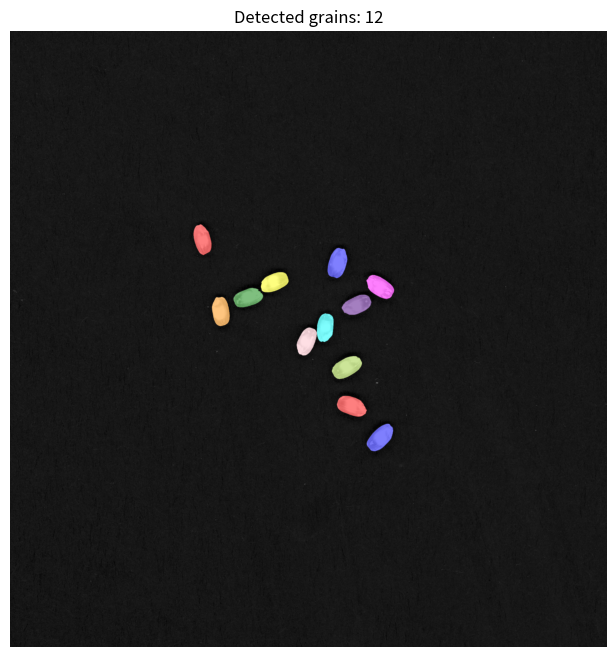

channels deprecated in v4.0.1+. If data contain more than 3 channels, only the first 3 channels will be used


Extracted 12 individual grain crops


In [4]:
import matplotlib.pyplot as plt
from skimage import io as skio

from sake_rice_inspection.preprocessing import segment_image

sample_image_path = Path("/private/data/curated/reflect/single/心白/10_心白（大）反射.jpg")

image = skio.imread(sample_image_path)
mask, region_df = segment_image(cp_model, image, min_area=1500, diameter=50)

plt.figure(figsize=(8, 8))
plt.imshow(render_overlay(image, mask))
plt.title(f"Detected grains: {mask.max()}")
plt.axis("off")
plt.show()

grains = process_image_to_grains(sample_image_path, cp_model, min_area=1500, diameter=50, margin=20)
print(f"Extracted {len(grains)} individual grain crops")